# 01 — Exploratory Data Analysis

Goal: profile the raw data and surface anything that shapes cleaning, features, and modelling.

## 1. Imports & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import poisson
from pathlib import Path

# Brand palette: Green → Yellow → Purple → Red
COLOURS = ['#027B5B', '#F9DC1C', '#54008B', '#D20F2D']
LEAGUE_ORDER = ['Premier League', 'Championship', 'League One']

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', None)

DATA_PATH = Path('../Data/match_data.csv')
OUT_PATH  = Path('../Outputs/EDA')
OUT_PATH.mkdir(parents=True, exist_ok=True)

# Hold-out boundary: seasons from here onward are the model's test set
# EDA must not see them, so everything below this notebook's load step is dev-only.
TEST_SEASON = '2024/2025'

## 2. Load & Inspect Data

Parse dates, temp split, confirm shape, and get a feel for the schema before anything else.

In [2]:
# Load the full dataset, then immediately remove test seet
df_full = pd.read_csv(DATA_PATH)

# Dev-only view: drop 2024/25 onward so no EDA decision is informed by the test set
df = df_full[df_full['season'] < TEST_SEASON].copy()

held_out = len(df_full) - len(df)
print(f'Full dataset            : {df_full.shape}')
print(f'EDA dev-only (< {TEST_SEASON}): {df.shape}  '
      f'[{held_out:,} rows from {TEST_SEASON} onward held out]')
df.head()

Full dataset            : (11239, 14)
EDA dev-only (< 2024/2025): (8751, 14)  [2,488 rows from 2024/2025 onward held out]


,league_name,season,date,game_week,home_team,home_id,away_team,away_id,home_goals,away_goals,home_xg,away_xg,is_neutral_venue,is_crowds
0,Championship,2018/2019,2018-08-03Z,1,Reading,25,Derby County,57,1,2,0.92820,0.72310,0,1
1,League One,2018/2019,2018-08-04Z,1,Sunderland,6,Charlton Athletic,81,2,1,NaN,NaN,0,1
2,Championship,2018/2019,2018-08-04Z,1,Birmingham City,38,Norwich City,20,2,2,1.30576,1.79621,0,1
3,Championship,2018/2019,2018-08-04Z,1,Brentford,72,Rotherham United,71,5,1,2.46905,0.64970,0,1
4,Championship,2018/2019,2018-08-04Z,1,Bristol City,28,Nottingham Forest,39,1,1,0.35720,0.72570,0,1


In [3]:
# Confirm all dates carry a trailing timezone letter before stripping
has_trailing = df['date'].astype(str).str.contains(r'[A-Za-z]$', na=False)
print(f'Rows with trailing letter: {has_trailing.sum():,} / {len(df):,} ({100 * has_trailing.mean():.0f}%)')

Rows with trailing letter: 8,751 / 8,751 (100%)


In [4]:
df['date'] = pd.to_datetime(df['date'].astype(str).str.replace(r'[A-Za-z]+$', '', regex=True))

print(f'Date range: {df["date"].min().date()} → {df["date"].max().date()}')

Date range: 2018-08-03 → 2024-05-19


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8751 entries, 0 to 8750
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   league_name       8751 non-null   str           
 1   season            8751 non-null   str           
 2   date              8751 non-null   datetime64[us]
 3   game_week         8751 non-null   int64         
 4   home_team         8751 non-null   str           
 5   home_id           8751 non-null   int64         
 6   away_team         8751 non-null   str           
 7   away_id           8751 non-null   int64         
 8   home_goals        8751 non-null   int64         
 9   away_goals        8751 non-null   int64         
 10  home_xg           8198 non-null   float64       
 11  away_xg           8197 non-null   float64       
 12  is_neutral_venue  8751 non-null   int64         
 13  is_crowds         8751 non-null   int64         
dtypes: datetime64[us](1), float64(2), i

## 3. Target Variable: Total Goals

Create the target and confirm total goals is approximately Poisson.

In [6]:
df['total_goals'] = df['home_goals'] + df['away_goals']

# Pre-compute overall mean once — reused throughout the notebook
OVERALL_MEAN = df['total_goals'].mean()

print(df['total_goals'].describe())

count    8751.000000
mean        2.653868
std         1.618273
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        10.000000
Name: total_goals, dtype: float64


In [7]:
# For a Poisson distribution, variance ≈ mean. A ratio near 1.0 validates the assumption.
print(f'Mean:     {OVERALL_MEAN:.3f}')
print(f'Variance: {df["total_goals"].var():.3f}')
print(f'Var/Mean: {df["total_goals"].var() / OVERALL_MEAN:.3f}')

Mean:     2.654
Variance: 2.619
Var/Mean: 0.987


In [8]:
# Compute actual proportions and expected Poisson probabilities
actual   = df['total_goals'].value_counts(normalize=True).sort_index()
expected = pd.Series(poisson.pmf(actual.index, OVERALL_MEAN), index=actual.index)

pd.DataFrame({'Actual': actual, 'Poisson': expected}).round(4)

,Actual,Poisson
total_goals,,
0,0.0704,0.0704
1,0.1841,0.1868
2,0.2481,0.2478
3,0.2242,0.2192
4,0.1416,0.1455
5,0.0811,0.0772
6,0.0317,0.0341
7,0.0135,0.0129
8,0.0039,0.0043


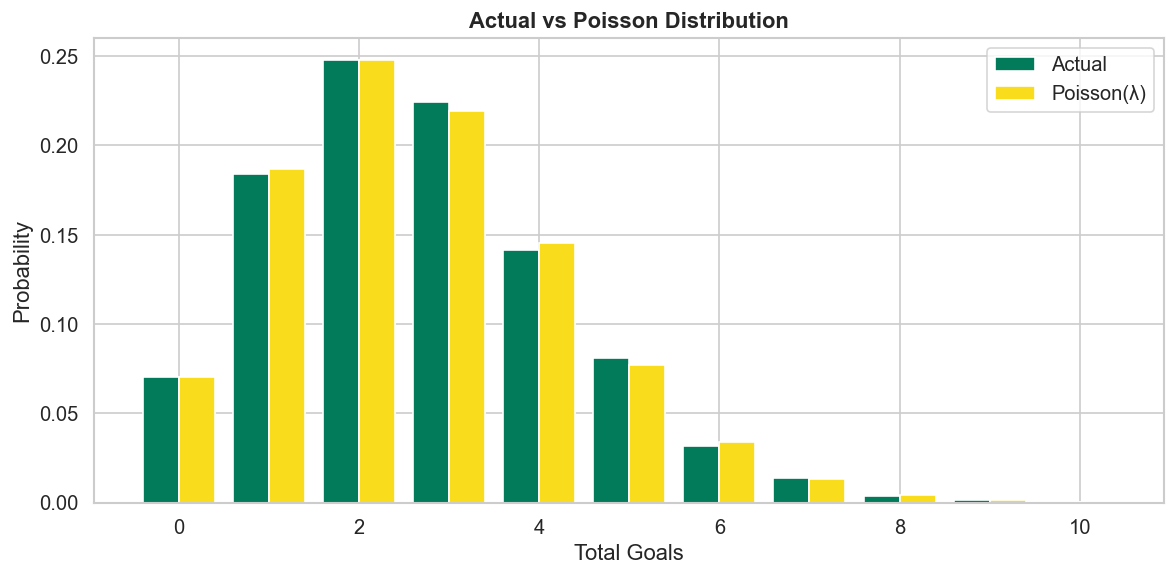

In [9]:
# Grouped bar: actual proportions vs Poisson — reuses `actual` and `expected` from above
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(actual.index - 0.2, actual.values,   width=0.4, color=COLOURS[0], label='Actual')
ax.bar(actual.index + 0.2, expected.values, width=0.4, color=COLOURS[1], label='Poisson(λ)')
ax.set_xlabel('Total Goals')
ax.set_ylabel('Probability')
ax.set_title('Actual vs Poisson Distribution', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_PATH / 'eda_poisson_fit.png', bbox_inches='tight')
plt.show()

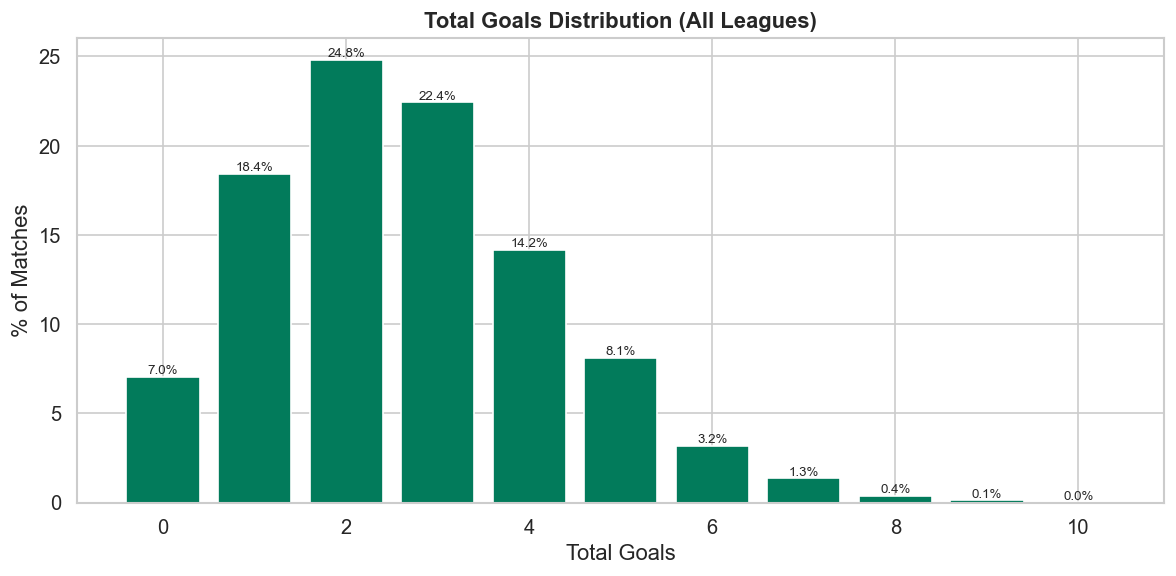

In [10]:
# Percentage bar with data labels
goal_pct = actual.mul(100)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(goal_pct.index, goal_pct.values, color=COLOURS[0])
for x, y in zip(goal_pct.index, goal_pct.values):
    ax.text(x, y, f'{y:.1f}%', ha='center', va='bottom', fontsize=8)
ax.set_xlabel('Total Goals')
ax.set_ylabel('% of Matches')
ax.set_title('Total Goals Distribution (All Leagues)', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_PATH / 'eda_goals_distribution_overall.png', bbox_inches='tight')
plt.show()

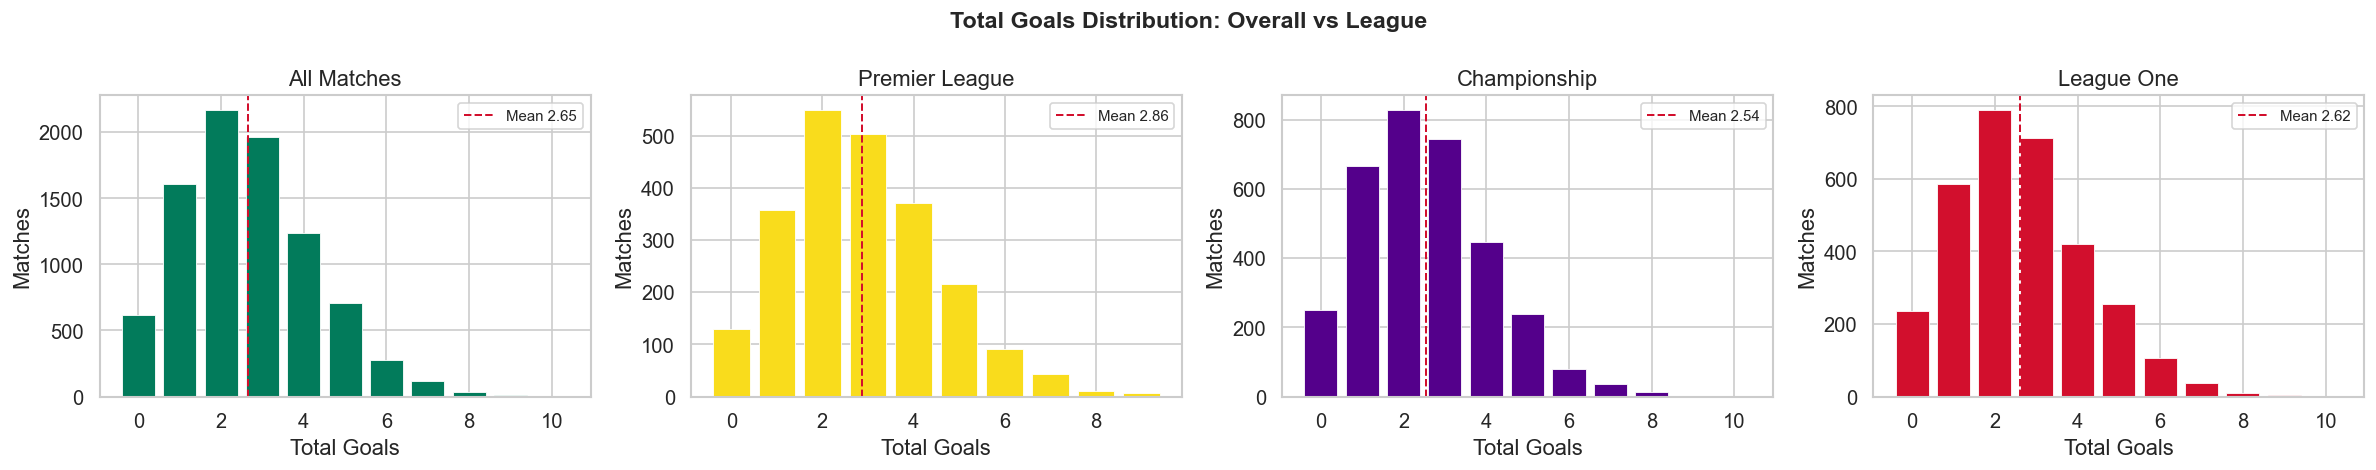

In [11]:
groups = [('All Matches', df)] + [(lg, df[df['league_name'] == lg]) for lg in LEAGUE_ORDER]

fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=False)
for ax, (title, subset), colour in zip(axes, groups, COLOURS):
    counts = subset['total_goals'].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=colour, edgecolor='white', linewidth=0.5)
    mean = subset['total_goals'].mean()
    ax.axvline(mean, color=COLOURS[3], linestyle='--', linewidth=1.2, label=f'Mean {mean:.2f}')
    ax.set_title(title)
    ax.set_xlabel('Total Goals')
    ax.set_ylabel('Matches')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(fontsize=9)

fig.suptitle('Total Goals Distribution: Overall vs League', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_PATH / 'eda_goals_distribution_by_league.png', bbox_inches='tight')
plt.show()

/var/folders/7t/bz9bdmjs5xxb3vbsk7r_l0q80000gn/T/ipykernel_1800/1543879992.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


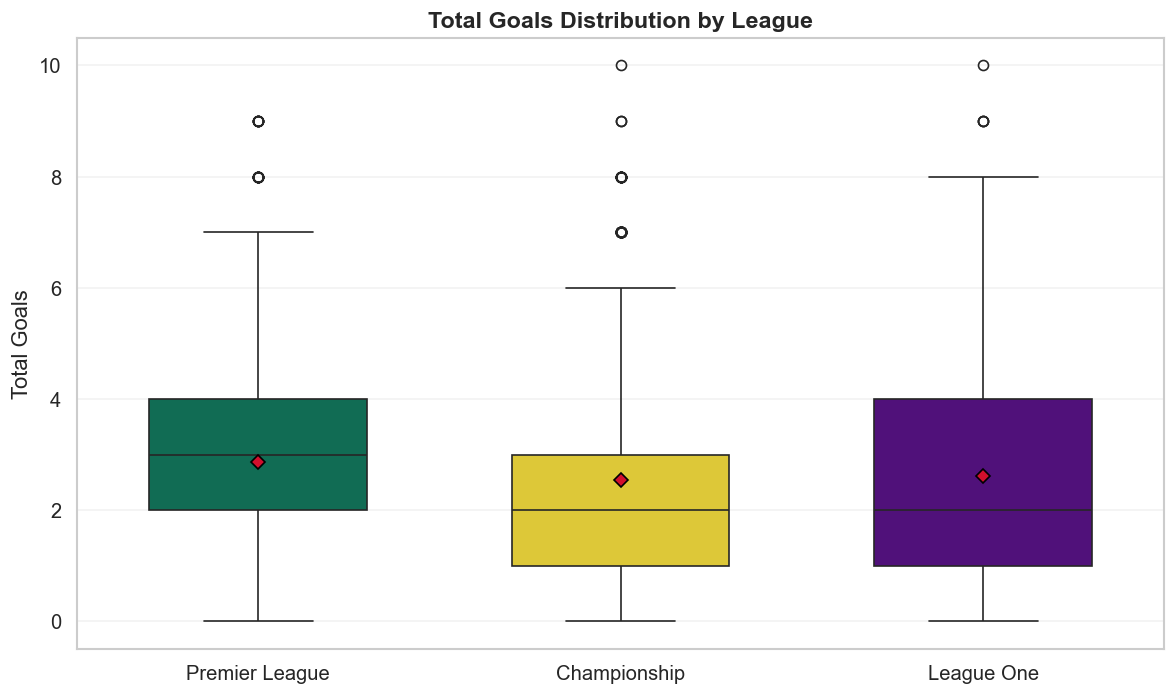

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=df, x='league_name', y='total_goals', order=LEAGUE_ORDER,
    palette=COLOURS[:3], width=0.6, ax=ax,
    showmeans=True,
    meanprops={'marker': 'D', 'markerfacecolor': COLOURS[3], 'markeredgecolor': 'black', 'markersize': 6}
)
ax.set_title('Total Goals Distribution by League', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Total Goals')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_PATH / 'eda_goals_boxplots.png', bbox_inches='tight')
plt.show()

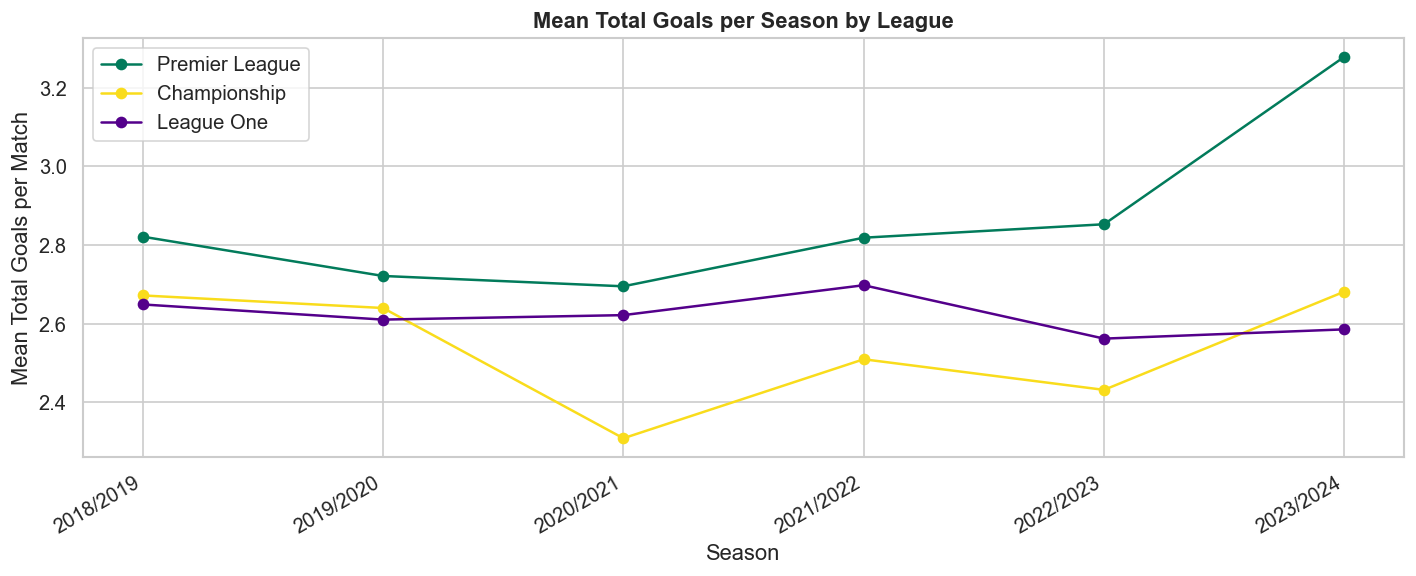

In [13]:
season_means = df.groupby(['league_name', 'season'])['total_goals'].mean().unstack('league_name')[LEAGUE_ORDER]

fig, ax = plt.subplots(figsize=(12, 5))
for col, colour in zip(season_means.columns, COLOURS):
    ax.plot(season_means.index, season_means[col], marker='o', label=col, color=colour)
ax.set_xlabel('Season')
ax.set_ylabel('Mean Total Goals per Match')
ax.set_title('Mean Total Goals per Season by League', fontweight='bold')
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUT_PATH / 'eda_goals_trend.png', bbox_inches='tight')
plt.show()

In [14]:
gameweek_summary = (
    df.groupby('game_week')
      .agg(matches=('total_goals', 'size'), avg_goals=('total_goals', 'mean'))
      .reset_index()
)
gameweek_summary.head()

,game_week,matches,avg_goals
0,1,203,2.576355
1,2,203,2.684729
2,3,203,2.665025
3,4,202,2.777228
4,5,203,2.527094


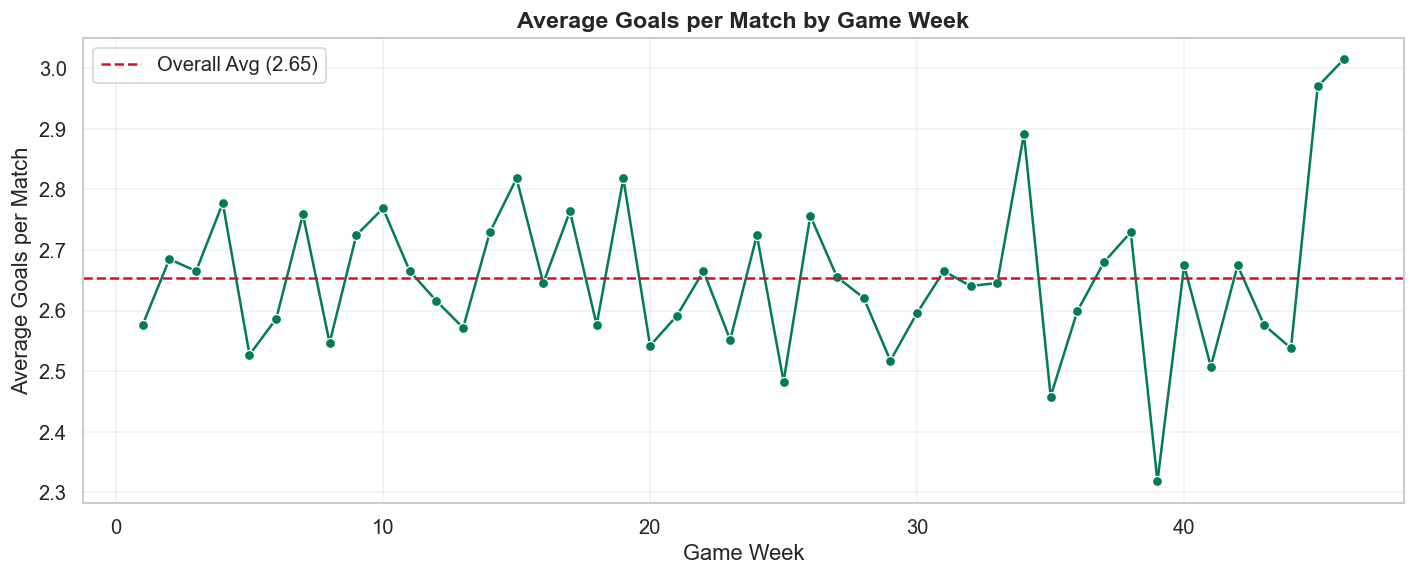

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=gameweek_summary, x='game_week', y='avg_goals', marker='o', color=COLOURS[0], ax=ax)
ax.axhline(OVERALL_MEAN, color=COLOURS[3], linestyle='--', label=f'Overall Avg ({OVERALL_MEAN:.2f})')
ax.set_title('Average Goals per Match by Game Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Game Week')
ax.set_ylabel('Average Goals per Match')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_PATH / 'eda_gameweek_goals.png', bbox_inches='tight')
plt.show()

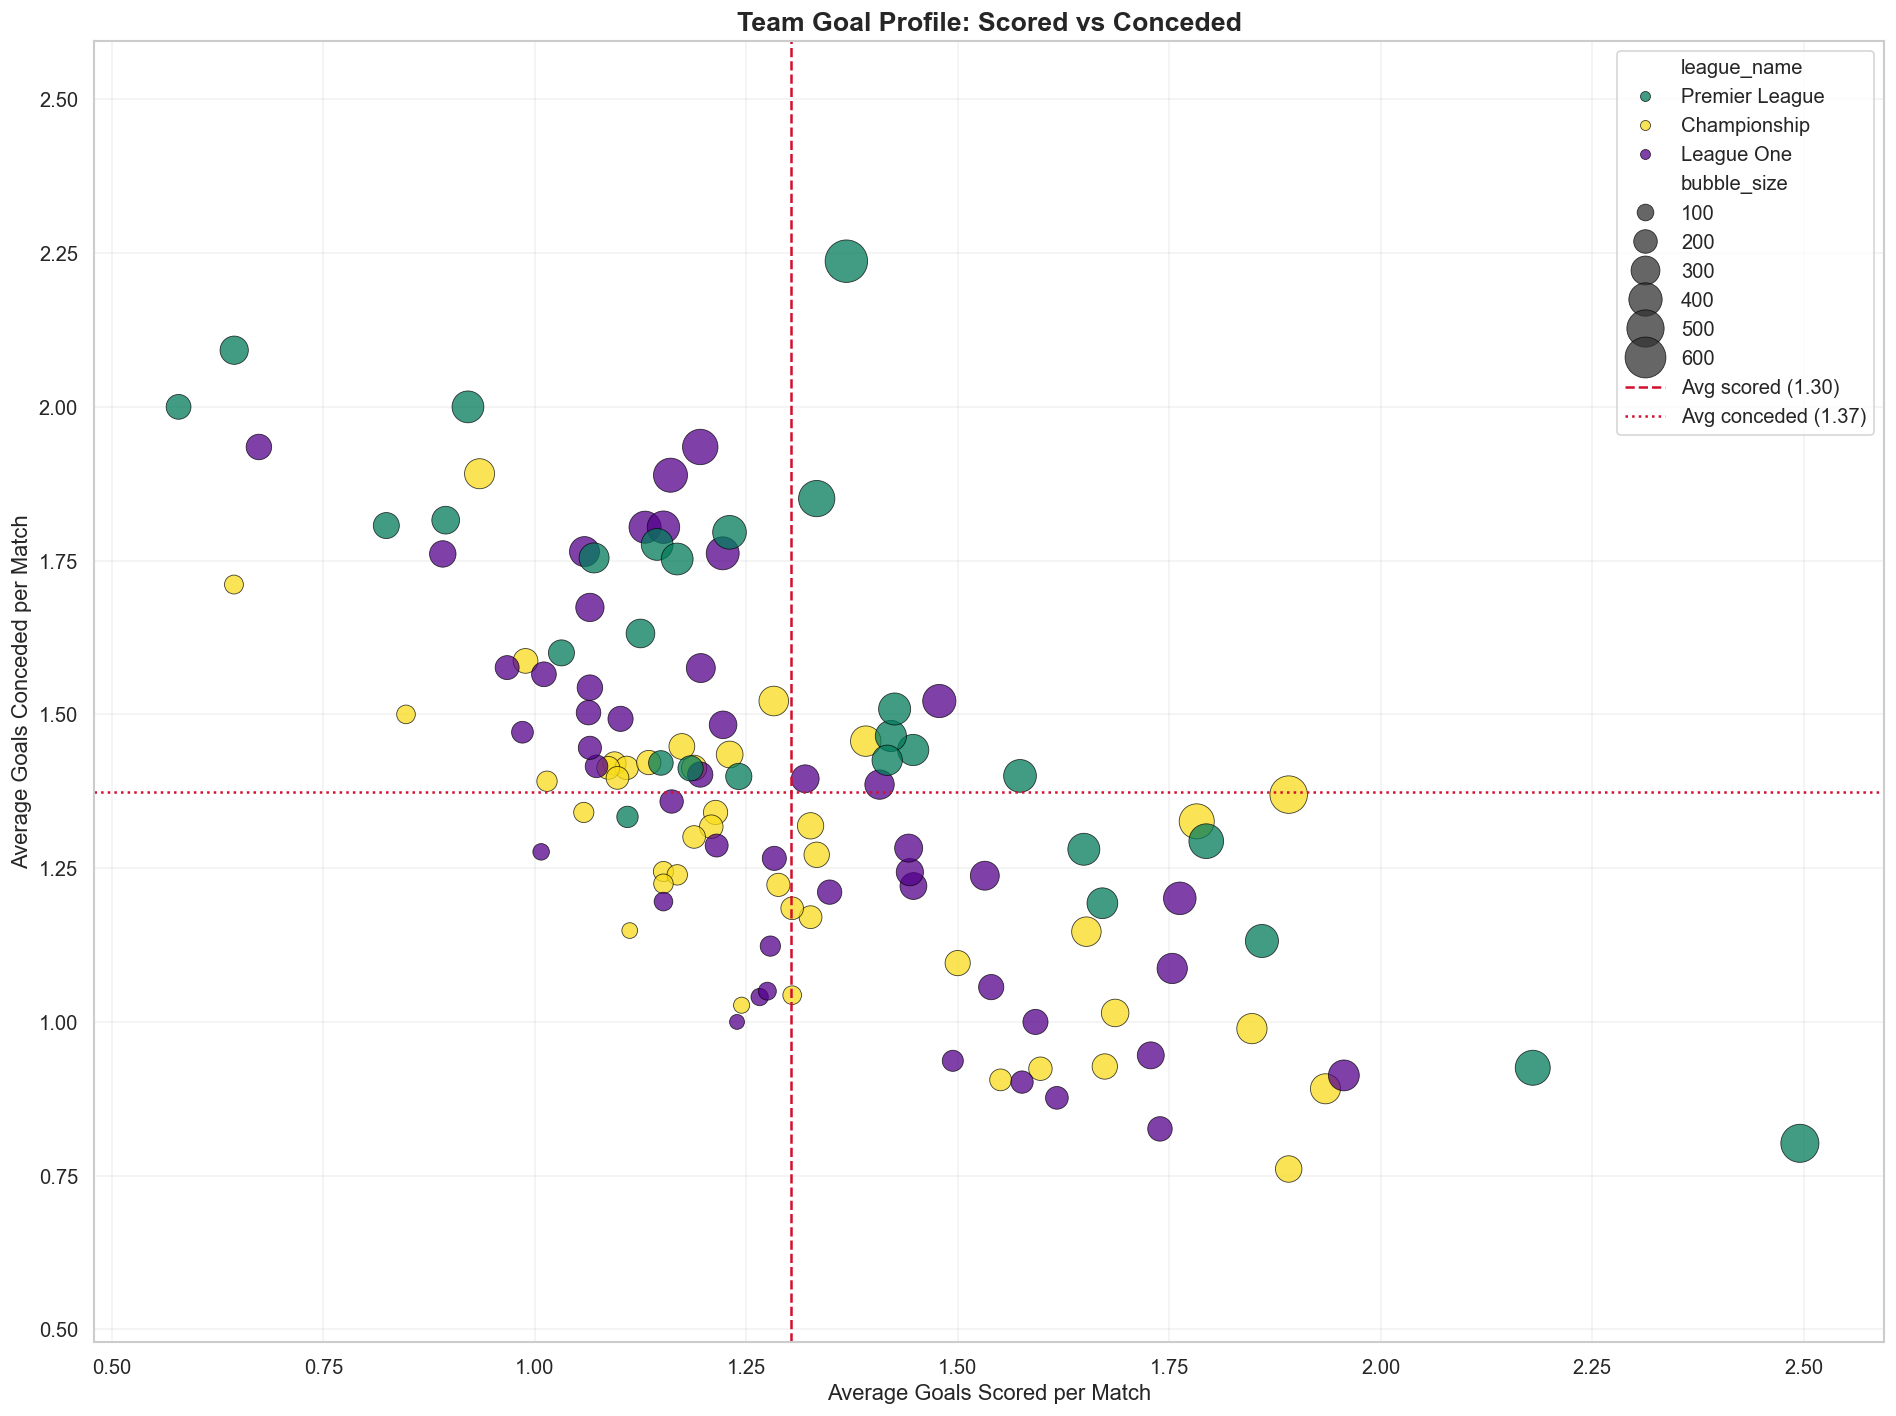

In [16]:
# Build per-team stats — computed separately for home and away appearances,
# then combined using a match-weighted average to avoid biasing teams with
# unequal home/away game counts.
home_stats = (
    df.groupby(['league_name', 'home_team'])
      .agg(avg_goals_scored=('home_goals', 'mean'), avg_goals_conceded=('away_goals', 'mean'),
           avg_total_goals=('total_goals', 'mean'), matches=('total_goals', 'size'))
      .reset_index().rename(columns={'home_team': 'team'})
)
away_stats = (
    df.groupby(['league_name', 'away_team'])
      .agg(avg_goals_scored=('away_goals', 'mean'), avg_goals_conceded=('home_goals', 'mean'),
           avg_total_goals=('total_goals', 'mean'), matches=('total_goals', 'size'))
      .reset_index().rename(columns={'away_team': 'team'})
)

# Weighted combine: each metric weighted by match count
team_stats = (
    pd.concat([home_stats, away_stats], ignore_index=True)
      .groupby(['league_name', 'team'], as_index=False)
      .apply(
          lambda x: pd.Series({
              'avg_goals_scored':   np.average(x['avg_goals_scored'],   weights=x['matches']),
              'avg_goals_conceded': np.average(x['avg_goals_conceded'], weights=x['matches']),
              'avg_total_goals':    np.average(x['avg_total_goals'],    weights=x['matches']),
              'matches': x['matches'].sum()
          }), include_groups=False
      ).reset_index(drop=True)
)

# Quadrant reference lines
avg_scored   = team_stats['avg_goals_scored'].mean()
avg_conceded = team_stats['avg_goals_conceded'].mean()

# Scale bubble size by the average total goals in matches involving each team
size_range = (80, 650)
min_tg, max_tg = team_stats['avg_total_goals'].min(), team_stats['avg_total_goals'].max()
team_stats['bubble_size'] = size_range[0] + ((team_stats['avg_total_goals'] - min_tg) / (max_tg - min_tg)) * (size_range[1] - size_range[0])

axis_lim = (
    min(team_stats['avg_goals_scored'].min(), team_stats['avg_goals_conceded'].min()) - 0.1,
    max(team_stats['avg_goals_scored'].max(), team_stats['avg_goals_conceded'].max()) + 0.1
)

fig, ax = plt.subplots(figsize=(16, 12))
sns.scatterplot(
    data=team_stats, x='avg_goals_scored', y='avg_goals_conceded',
    hue='league_name', hue_order=LEAGUE_ORDER,
    palette=COLOURS[:3], size='bubble_size', sizes=size_range,
    alpha=0.75, edgecolor='black', linewidth=0.5, legend='brief', ax=ax
)
ax.axvline(avg_scored,   color=COLOURS[3], linestyle='--', linewidth=1.5, label=f'Avg scored ({avg_scored:.2f})')
ax.axhline(avg_conceded, color=COLOURS[3], linestyle=':',  linewidth=1.5, label=f'Avg conceded ({avg_conceded:.2f})')
ax.set_xlim(*axis_lim)
ax.set_ylim(*axis_lim)
ax.set_title('Team Goal Profile: Scored vs Conceded', fontsize=16, fontweight='bold')
ax.set_xlabel('Average Goals Scored per Match')
ax.set_ylabel('Average Goals Conceded per Match')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_PATH / 'eda_team_goal_profile_quadrants.png', bbox_inches='tight')
plt.show()

## 4. Neutral Venue

Quick check before committing to home/away feature splits.

In [17]:
pd.concat(
    [df['is_neutral_venue'].value_counts(), df['is_neutral_venue'].value_counts(normalize=True).mul(100).round(2)],
    axis=1, keys=['Count', 'Percent']
)

,Count,Percent
is_neutral_venue,,
0,8751,100.0


All 11,239 matches are played at home grounds — `is_neutral_venue` is zero-variance and will be dropped in feature engineering.

## 5. xG Coverage

Where xG is present vs absent — this shapes the per-league feature strategy.

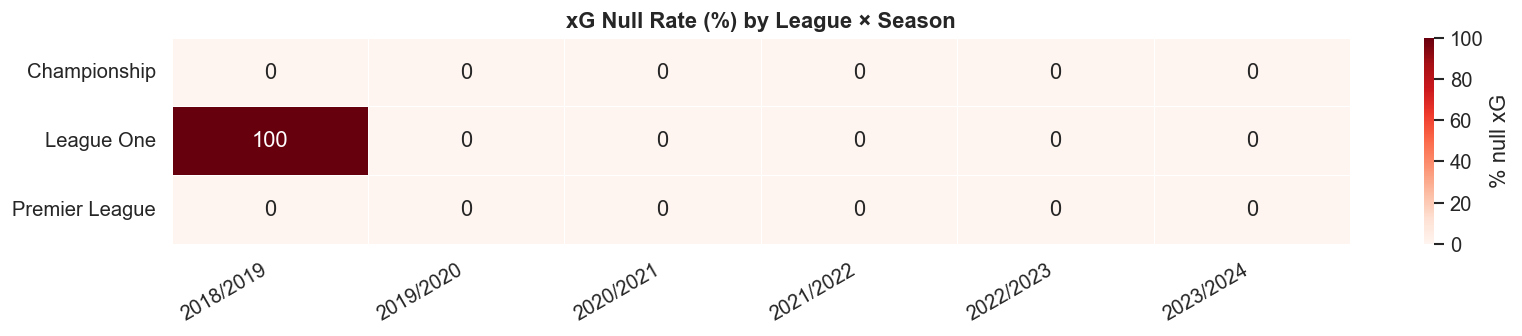

Overall null rate by league:
league_name
Championship       0.0%
League One        17.5%
Premier League     0.0%
Name: home_xg, dtype: str


In [18]:
# xG null rate by league × season
xg_null = (
    df.groupby(['league_name', 'season'])['home_xg']
      .apply(lambda s: s.isna().mean() * 100)
      .unstack('season')
)

fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(xg_null, annot=True, fmt='.0f', cmap='Reds', linewidths=0.5,
            ax=ax, cbar_kws={'label': '% null xG'})
ax.set_title('xG Null Rate (%) by League × Season', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUT_PATH / 'eda_xg_coverage.png', bbox_inches='tight')
plt.show()

print('Overall null rate by league:')
print(df.groupby('league_name')['home_xg'].apply(lambda s: f'{s.isna().mean()*100:.1f}%'))

In [19]:
df['total_xg']    = df['home_xg'] + df['away_xg']
df['xg_residual'] = df['total_goals'] - df['total_xg']

print(f'total_xg — missing: {df["total_xg"].isna().sum():,} | available: {df["total_xg"].notna().sum():,}')
print(df['total_xg'].describe())

total_xg — missing: 555 | available: 8,196
count    8196.000000
mean        2.583930
std         0.979718
min         0.274900
25%         1.872175
50%         2.485300
75%         3.171100
max         7.715200
Name: total_xg, dtype: float64


Pearson r(total_xg, total_goals): 0.518


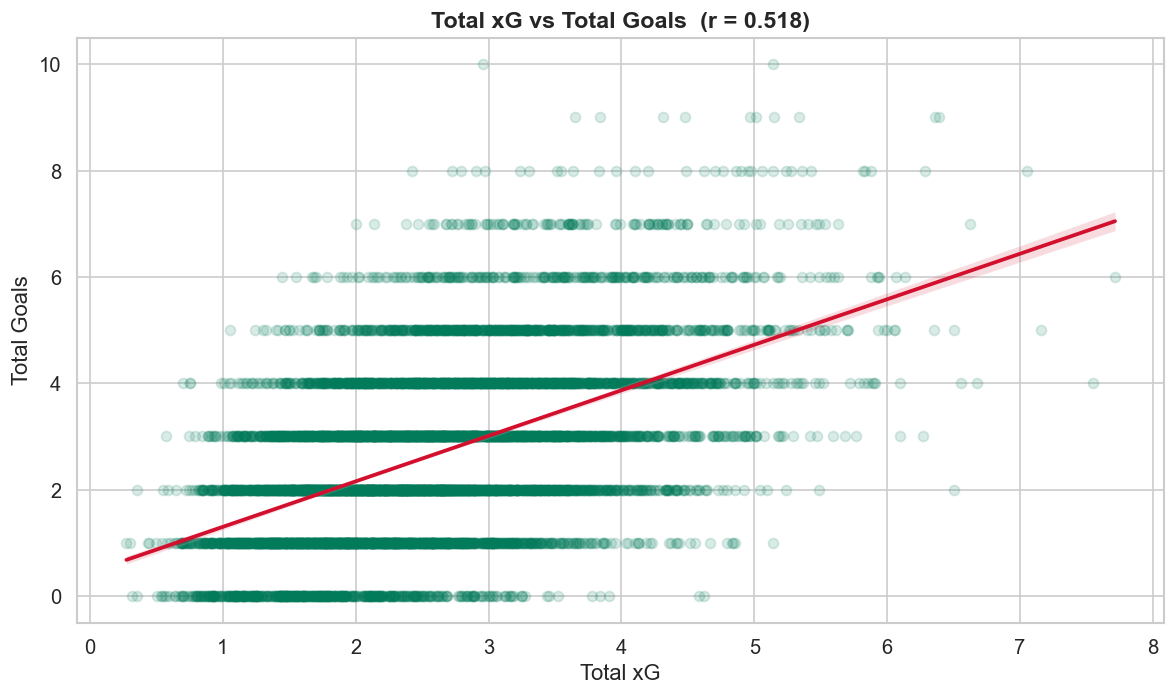

In [20]:
corr = df[['total_xg', 'total_goals']].corr().iloc[0, 1]
print(f'Pearson r(total_xg, total_goals): {corr:.3f}')

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=df, x='total_xg', y='total_goals',
            scatter_kws={'alpha': 0.15, 'color': COLOURS[0]},
            line_kws={'color': COLOURS[3]}, ax=ax)
ax.set_title(f'Total xG vs Total Goals  (r = {corr:.3f})', fontsize=14, fontweight='bold')
ax.set_xlabel('Total xG')
ax.set_ylabel('Total Goals')
plt.tight_layout()
plt.savefig(OUT_PATH / 'eda_total_xg_vs_goals.png', bbox_inches='tight')
plt.show()

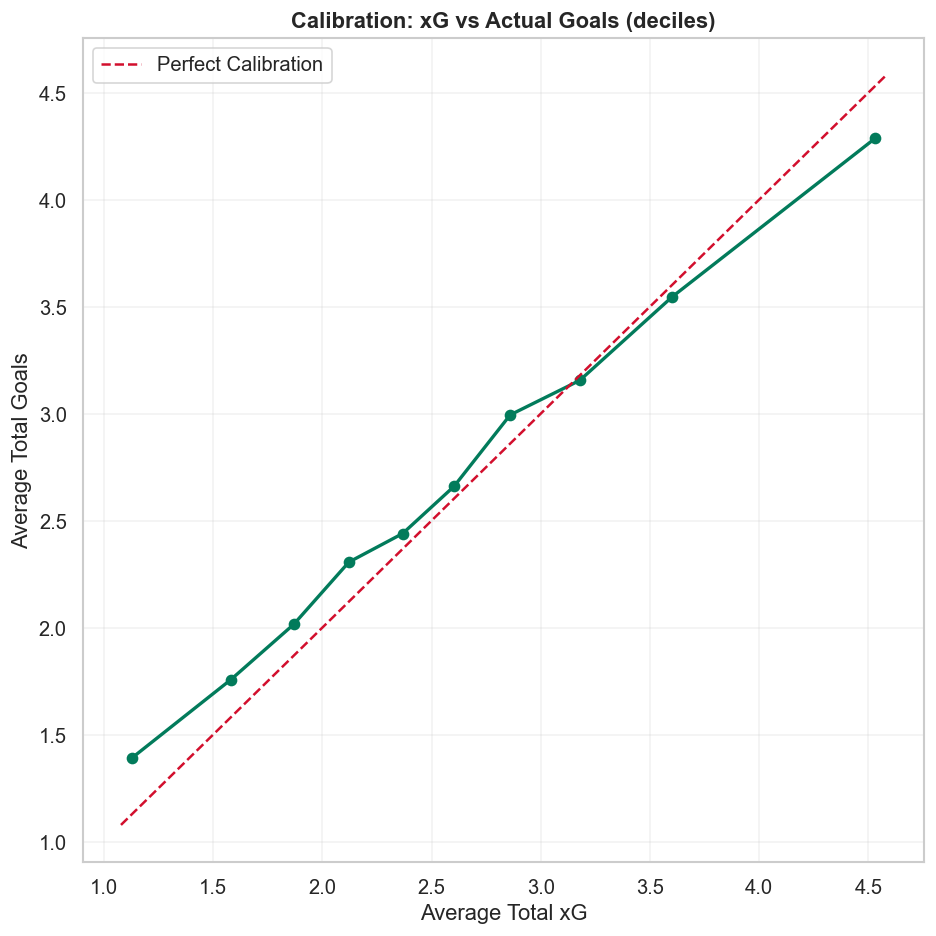

In [21]:
# Calibration: bin matches by total xG decile, compare mean xG vs mean actual goals
calibration = (
    df.dropna(subset=['total_xg'])
      .assign(xg_bin=lambda x: pd.qcut(x['total_xg'], q=10, duplicates='drop'))
      .groupby('xg_bin')
      .agg(avg_xg=('total_xg', 'mean'), avg_goals=('total_goals', 'mean'), matches=('total_goals', 'size'))
      .reset_index()
)

lim = (min(calibration['avg_xg'].min(), calibration['avg_goals'].min()) - 0.05,
       max(calibration['avg_xg'].max(), calibration['avg_goals'].max()) + 0.05)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(calibration['avg_xg'], calibration['avg_goals'], marker='o', linewidth=2, color=COLOURS[0])
ax.plot(lim, lim, linestyle='--', color=COLOURS[3], label='Perfect Calibration')
ax.set_xlabel('Average Total xG')
ax.set_ylabel('Average Total Goals')
ax.set_title('Calibration: xG vs Actual Goals (deciles)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_PATH / 'eda_xg_calibration.png', bbox_inches='tight')
plt.show()

count    8196.000000
mean        0.070902
std         1.393826
min        -4.618100
25%        -0.892180
50%        -0.024820
75%         0.951475
max         7.039000
Name: xg_residual, dtype: float64


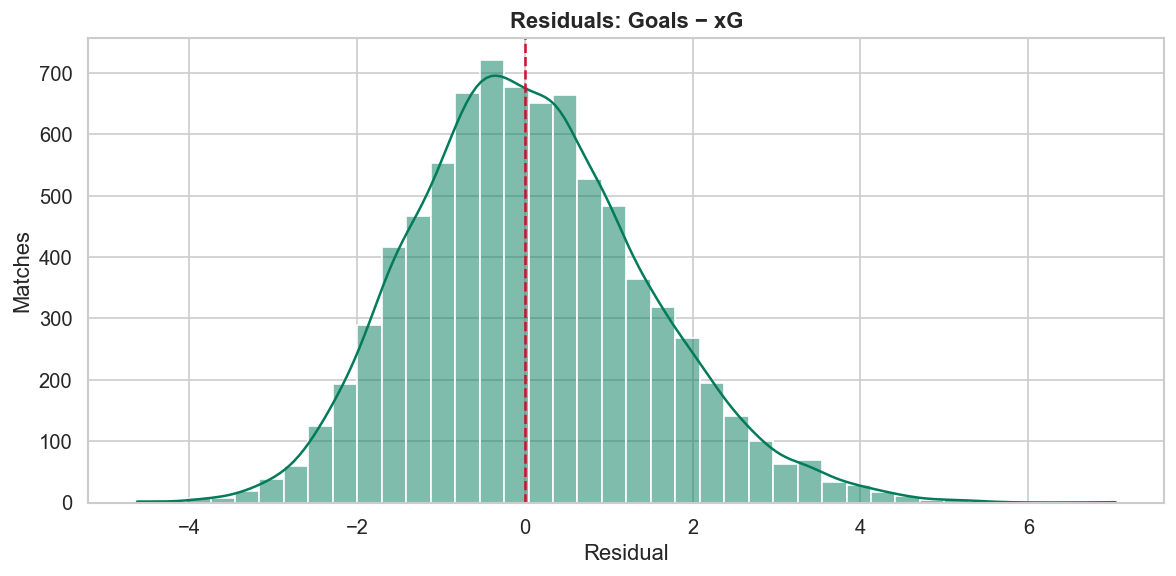

In [22]:
print(df['xg_residual'].describe())

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['xg_residual'], bins=40, kde=True, color=COLOURS[0], ax=ax)
ax.axvline(0, color=COLOURS[3], linestyle='--')
ax.set_title('Residuals: Goals − xG', fontweight='bold')
ax.set_xlabel('Residual')
ax.set_ylabel('Matches')
plt.tight_layout()
plt.savefig(OUT_PATH / 'eda_xg_residuals.png', bbox_inches='tight')
plt.show()

## 6. COVID Era (No-Crowd Matches)

Check whether no-crowd (COVID) matches shifted goal rates and home advantage.

In [23]:
covid = df[df['is_crowds'] == 0]
print(f'No-crowd matches: {len(covid):,} of {len(df):,} ({len(covid)/len(df)*100:.1f}%)')
print(f'\nBreakdown by league and season:')
print(covid.groupby(['league_name', 'season']).size().to_string())

No-crowd matches: 1,601 of 8,751 (18.3%)

Breakdown by league and season:
league_name     season   
Championship    2019/2020    108
                2020/2021    529
                2021/2022      1
League One      2020/2021    526
Premier League  2019/2020     92
                2020/2021    345


In [24]:
crowd_summary = (
    df.groupby('is_crowds')
      .agg(matches=('total_goals', 'size'), avg_total_goals=('total_goals', 'mean'),
           avg_home_goals=('home_goals', 'mean'), avg_away_goals=('away_goals', 'mean'))
)
crowd_summary['home_advantage'] = crowd_summary['avg_home_goals'] - crowd_summary['avg_away_goals']
crowd_summary.index = ['No Crowd (COVID)', 'With Crowd']
crowd_summary.round(3)

,matches,avg_total_goals,avg_home_goals,avg_away_goals,home_advantage
No Crowd (COVID),1601,2.536,1.319,1.217,0.101
With Crowd,7150,2.680,1.484,1.196,0.288


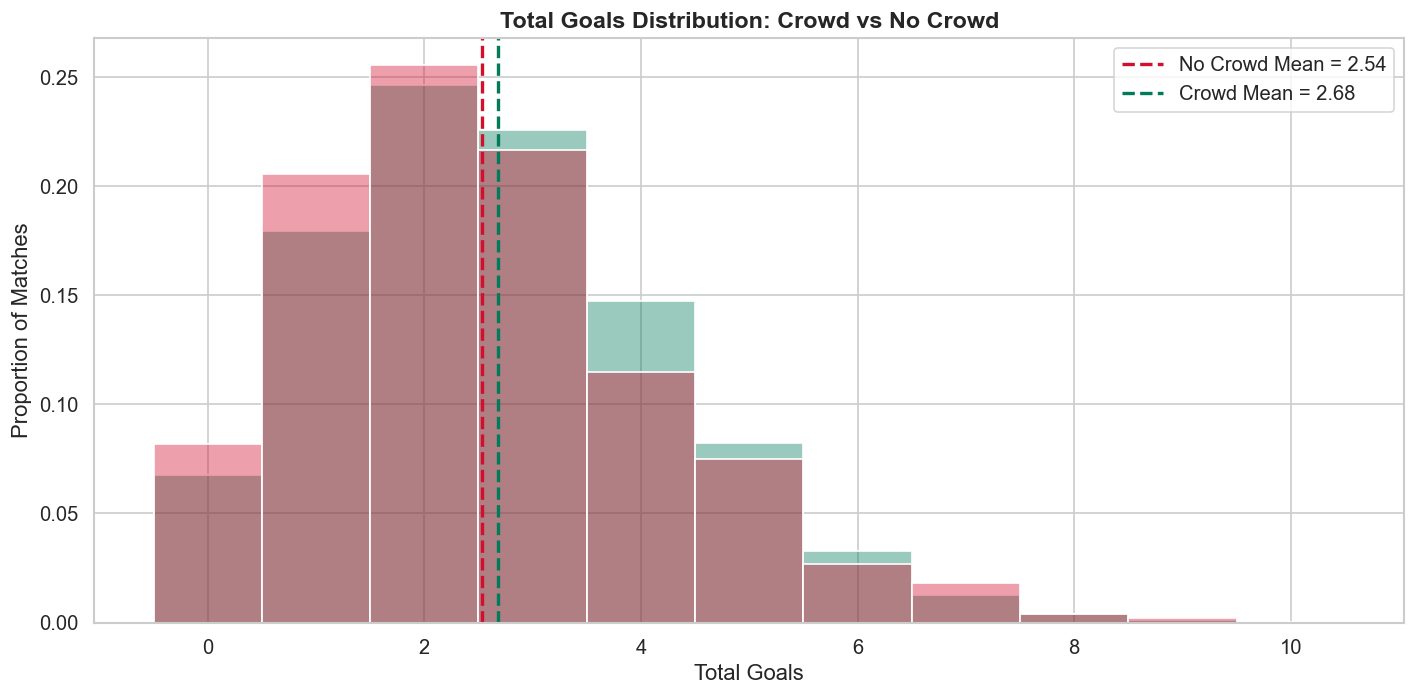

In [25]:
# Pull pre-computed means from crowd_summary to avoid recalculation
mean_no_crowd = crowd_summary.loc['No Crowd (COVID)', 'avg_total_goals']
mean_crowd    = crowd_summary.loc['With Crowd',       'avg_total_goals']

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(data=df, x='total_goals', hue='is_crowds', stat='probability',
             common_norm=False, discrete=True, multiple='layer', alpha=0.4,
             palette=[COLOURS[3], COLOURS[0]], ax=ax)
ax.axvline(mean_no_crowd, color=COLOURS[3], linestyle='--', linewidth=2, label=f'No Crowd Mean = {mean_no_crowd:.2f}')
ax.axvline(mean_crowd,    color=COLOURS[0], linestyle='--', linewidth=2, label=f'Crowd Mean = {mean_crowd:.2f}')
ax.set_title('Total Goals Distribution: Crowd vs No Crowd', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Goals')
ax.set_ylabel('Proportion of Matches')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_PATH / 'eda_crowd_vs_no_crowd_distribution.png', bbox_inches='tight')
plt.show()

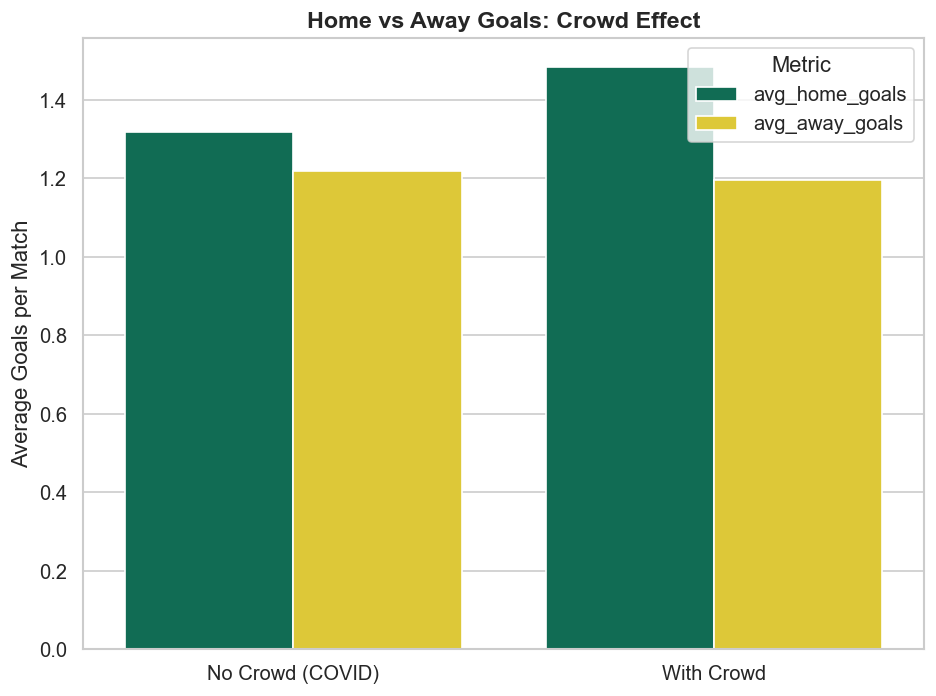

In [26]:
# Reshape crowd_summary for grouped bar — reuses aggregated values, no re-computation needed.
# reset_index(names=...) required because renaming the index values above strips the index name.
plot_df = (
    crowd_summary[['avg_home_goals', 'avg_away_goals']]
      .reset_index(names='Crowd')
      .melt(id_vars='Crowd', var_name='Metric', value_name='Goals')
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=plot_df, x='Crowd', y='Goals', hue='Metric',
            palette=[COLOURS[0], COLOURS[1]], ax=ax)
ax.set_title('Home vs Away Goals: Crowd Effect', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Average Goals per Match')
plt.tight_layout()
plt.savefig(OUT_PATH / 'eda_home_advantage_crowds.png', bbox_inches='tight')
plt.show()

## 7. Home Advantage by League

Confirm home advantage is consistent across leagues.

                home_goals  away_goals  home_advantage
league_name                                           
Premier League       1.564       1.300           0.264
Championship         1.400       1.140           0.260
League One           1.430       1.191           0.239


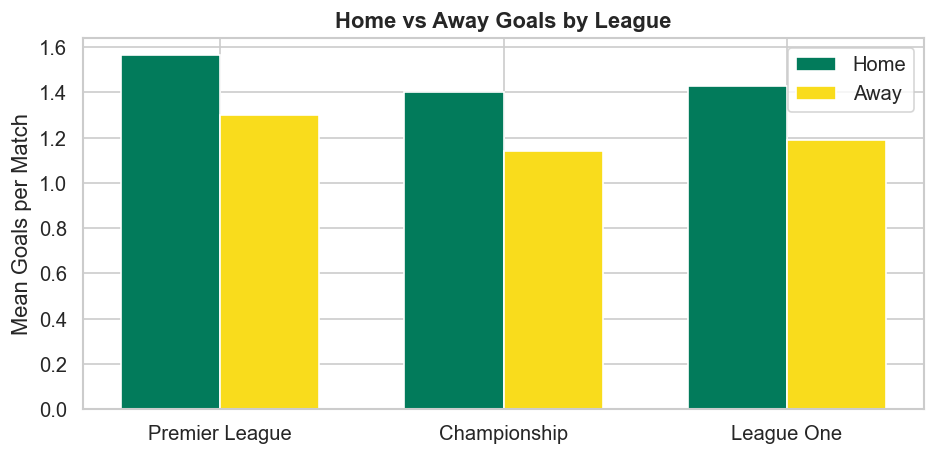

In [27]:
ha = df.groupby('league_name')[['home_goals', 'away_goals']].mean().loc[LEAGUE_ORDER].round(3)
ha['home_advantage'] = ha['home_goals'] - ha['away_goals']
print(ha)

x = np.arange(len(ha))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, ha['home_goals'], width, label='Home', color=COLOURS[0])
ax.bar(x + width/2, ha['away_goals'], width, label='Away', color=COLOURS[1])
ax.set_xticks(x)
ax.set_xticklabels(ha.index)
ax.set_ylabel('Mean Goals per Match')
ax.set_title('Home vs Away Goals by League', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_PATH / 'eda_home_advantage.png', bbox_inches='tight')
plt.show()